In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report

In [ ]:
csv_id = '1gbfFzWO0A13gcKCULvnwdPaoY-cUeqoN'
csv_url = f'https://drive.google.com/uc?export=download&id={csv_id}'

df = pd.read_csv(csv_url)

if 'FILENAME' in df.columns:
    df = df.drop(columns=['FILENAME'])

csv_id = '1LXtyTZK0RXPhjFsVIFLcScW7JXSdC8CH'
csv_url = f'https://drive.google.com/uc?export=download&id={csv_id}'

df_46 = pd.read_csv(csv_url)

if 'label' in df_46.columns:
    df_46 = df_46.drop(columns=['label'])

csv_id = '15WFduozUE2p88LigOMzJ9fa7uxEpSJAj'
csv_url = f'https://drive.google.com/uc?export=download&id={csv_id}'

df_45 = pd.read_csv(csv_url)

if 'label' in df_45.columns:
    df_45 = df_45.drop(columns=['label'])

csv_id = '1snEz-tUsKV8BBlbc74v7qWTfTfnhPyVR'
csv_url = f'https://drive.google.com/uc?export=download&id={csv_id}'

df_35 = pd.read_csv(csv_url)

if 'label' in df_35.columns:
    df_35 = df_35.drop(columns=['label'])


display(df)
display(df_46)
display(df_45)
display(df_35)

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.000000,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.000000,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.000000,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.000000,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.000000,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,0.058739,...,1,0,1,51,7,21,187,2,191,1
235791,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,0.053834,...,1,0,0,50,1,7,88,0,31,1
235792,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,0.063093,...,0,0,1,27,10,30,58,2,67,1
235793,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,0.050211,...,0,0,0,0,0,3,0,0,0,0


,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,31,24,0,1.000000,3,1,0,0,0.0,18,...,1,0,0,1,34,20,28,119,0,124
1,23,16,0,0.666667,2,1,0,0,0.0,9,...,0,0,0,1,50,9,8,39,0,217
2,29,22,0,0.866667,2,2,0,0,0.0,15,...,0,0,0,1,10,2,7,42,2,5
3,26,19,0,1.000000,3,1,0,0,0.0,13,...,0,1,1,1,3,27,15,22,1,31
4,33,26,0,1.000000,3,1,0,0,0.0,20,...,1,1,0,1,244,15,34,72,1,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,29,22,0,1.000000,3,1,0,0,0.0,16,...,0,1,0,1,51,7,21,187,2,191
235791,28,21,0,0.785714,2,2,0,0,0.0,14,...,0,1,0,0,50,1,7,88,0,31
235792,30,23,0,1.000000,2,1,0,0,0.0,17,...,0,0,0,1,27,10,30,58,2,67
235793,55,47,0,0.465116,3,2,0,0,0.0,39,...,0,0,0,0,0,0,3,0,0,0


,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLength,NoOfSubDomain,HasObfuscation,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,31,24,0,1.000000,3,1,0,0.0,18,0.581,...,1,0,0,1,34,20,28,119,0,124
1,23,16,0,0.666667,2,1,0,0.0,9,0.391,...,0,0,0,1,50,9,8,39,0,217
2,29,22,0,0.866667,2,2,0,0.0,15,0.517,...,0,0,0,1,10,2,7,42,2,5
3,26,19,0,1.000000,3,1,0,0.0,13,0.500,...,0,1,1,1,3,27,15,22,1,31
4,33,26,0,1.000000,3,1,0,0.0,20,0.606,...,1,1,0,1,244,15,34,72,1,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,29,22,0,1.000000,3,1,0,0.0,16,0.552,...,0,1,0,1,51,7,21,187,2,191
235791,28,21,0,0.785714,2,2,0,0.0,14,0.500,...,0,1,0,0,50,1,7,88,0,31
235792,30,23,0,1.000000,2,1,0,0.0,17,0.567,...,0,0,0,1,27,10,30,58,2,67
235793,55,47,0,0.465116,3,2,0,0.0,39,0.709,...,0,0,0,0,0,0,3,0,0,0


,URLLength,DomainLength,CharContinuationRate,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfQMarkInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,...,HasPasswordField,Bank,Pay,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,31,24,1.000000,18,0.581,0,0.000,0,1,0.032,...,0,1,0,1,34,20,28,119,0,124
1,23,16,0.666667,9,0.391,0,0.000,0,2,0.087,...,0,0,0,1,50,9,8,39,0,217
2,29,22,0.866667,15,0.517,0,0.000,0,2,0.069,...,0,0,0,1,10,2,7,42,2,5
3,26,19,1.000000,13,0.500,0,0.000,0,1,0.038,...,0,0,1,1,3,27,15,22,1,31
4,33,26,1.000000,20,0.606,0,0.000,0,1,0.030,...,0,1,1,1,244,15,34,72,1,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,29,22,1.000000,16,0.552,0,0.000,0,1,0.034,...,0,0,1,1,51,7,21,187,2,191
235791,28,21,0.785714,14,0.500,0,0.000,0,2,0.071,...,0,0,1,0,50,1,7,88,0,31
235792,30,23,1.000000,17,0.567,0,0.000,0,1,0.033,...,0,0,0,1,27,10,30,58,2,67
235793,55,47,0.465116,39,0.709,3,0.055,0,5,0.091,...,1,0,0,0,0,0,3,0,0,0


### Preparação Inicial dos Dados

Nesta etapa, preparamos a base de dados para a aplicação dos modelos de aprendizado não-supervisionado (*PCA*, *K-Means* e *Isolation Forest*). O objetivo principal do bloco abaixo é estruturar diferentes versões do dataset para avaliar como a seleção prévia de atributos afeta a capacidade matemática dos algoritmos de separar naturalmente as URLs legítimas das de *phishing*.

Isolamos a coluna `label` das *features*. Como os algoritmos são não-supervisionados, eles devem processar os dados de forma "cega", e utilizaremos essas respostas salvas apenas na etapa final para medir a performance.


Filtramos os dados para reter apenas valores numéricos, um pré-requisito técnico para cálculos de matrizes (PCA) e distâncias espaciais (K-Means).

Por fim aplicamos o `StandardScaler` em todos os nossos datasets. Esta etapa é crucial para modelos baseados em distância, pois garante que atributos com escalas numéricas amplas não dominem ou anulem o peso de atributos menores.

In [ ]:
# Guardamos a variável alvo separadamente para a avaliação futura
labels = df['label'].copy()

# Criamos o dataset original contendo apenas as features, sem as respostas
df_original = df.drop(columns=['label'])

# Fazemos o dataset reduzido pelo pré-processamento de dados retirando as
# colunas desnecessárias
colunas_para_remover = [
    'URL', 'Domain', 'Title', 'TLD',
    'URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb', 'DegitRatioInURL',
    'HasObfuscation', 'NoOfCSS','NoOfImage', 'NoOfLettersInURL',
    'NoOfQMarkInURL','ObfuscationRatio', 'URLTitleMatchScore'
]

df_reduzido = df_original.drop(columns=colunas_para_remover, errors='ignore')

# PCA e K-Means exigem dados estritamente numéricos.
# Vamos garantir que eventuais colunas categóricas fiquem de fora do Scaler.
df_original_num = df_original.select_dtypes(include=[np.number])
df_reduzido_num = df_reduzido.select_dtypes(include=[np.number])
df_46_num = df_46.select_dtypes(include=[np.number])
df_45_num = df_45.select_dtypes(include=[np.number])
df_35_num = df_35.select_dtypes(include=[np.number])

# Padronizamos os datasets com StandardScaler
scaler_orig = StandardScaler()
X_original_scaled = scaler_orig.fit_transform(df_original_num)

scaler_red = StandardScaler()
X_reduzido_scaled = scaler_red.fit_transform(df_reduzido_num)

scaler_46 = StandardScaler()
X_46_scaled = scaler_46.fit_transform(df_46_num)

scaler_45 = StandardScaler()
X_45_scaled = scaler_45.fit_transform(df_45_num)

scaler_35 = StandardScaler()
X_35_scaled = scaler_35.fit_transform(df_35_num)

print(f"Dataset Original Escalonado: {X_original_scaled.shape[0]} linhas e {X_original_scaled.shape[1]} colunas")
print(f"Dataset Reduzido Escalonado: {X_reduzido_scaled.shape[0]} linhas e {X_reduzido_scaled.shape[1]} colunas")
print(f"Dataset 46 Escalonado: {X_46_scaled.shape[0]} linhas e {X_46_scaled.shape[1]} colunas")
print(f"Dataset 45 Escalonado: {X_45_scaled.shape[0]} linhas e {X_45_scaled.shape[1]} colunas")
print(f"Dataset 35 Escalonado: {X_35_scaled.shape[0]} linhas e {X_35_scaled.shape[1]} colunas")
print(f"Labels guardadas: {labels.shape[0]}")

Dataset Original Escalonado: 235795 linhas e 50 colunas
Dataset Reduzido Escalonado: 235795 linhas e 39 colunas
Dataset 46 Escalonado: 235795 linhas e 45 colunas
Dataset 45 Escalonado: 235795 linhas e 44 colunas
Dataset 35 Escalonado: 235795 linhas e 34 colunas
Labels guardadas: 235795


Abaixo, aplicamos o PCA a todos os nossos datasets e fazemos gráficos de variância com cada um deles para observar quantas componentes são necessárias para capturar 90% da variância de nosso dataset original. Isso nos garante que estamos capturando o padrão de nosso dataset original mas deixando de lado o "ruído" que pode causar overfitting em nossos modelos.

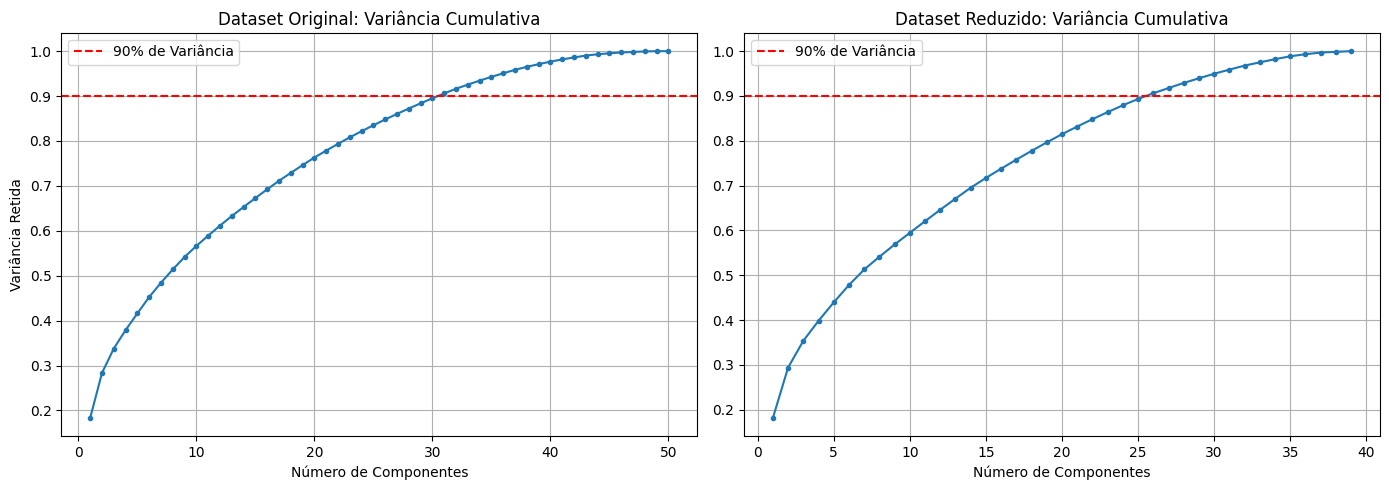

In [ ]:
# === Gráfico de Variância ===

# Instanciando o PCA
pca_orig = PCA()
pca_red = PCA()
pca_46 = PCA()
pca_45 = PCA()
pca_35 = PCA()

# Treinando (encontrando os componentes principais)
pca_orig.fit(X_original_scaled)
pca_red.fit(X_reduzido_scaled)
pca_46.fit(X_46_scaled)
pca_45.fit(X_45_scaled)
pca_35.fit(X_35_scaled)

# Calculando a soma cumulativa da variância explicada
var_cumulativa_orig = np.cumsum(pca_orig.explained_variance_ratio_)
var_cumulativa_red = np.cumsum(pca_red.explained_variance_ratio_)
var_cumulativa_46 = np.cumsum(pca_46.explained_variance_ratio_)
var_cumulativa_45 = np.cumsum(pca_45.explained_variance_ratio_)
var_cumulativa_35 = np.cumsum(pca_35.explained_variance_ratio_)

# Plotando as curvas do dataset original e reduzido lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Original
axes[0].plot(range(1, len(var_cumulativa_orig) + 1), var_cumulativa_orig, marker='.', linestyle='-')
axes[0].axhline(y=0.90, color='r', linestyle='--', label='90% de Variância') # Linha de corte em 90%
axes[0].set_title('Dataset Original: Variância Cumulativa')
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Variância Retida')
axes[0].legend()
axes[0].grid(True)

# Gráfico Reduzido
axes[1].plot(range(1, len(var_cumulativa_red) + 1), var_cumulativa_red, marker='.', linestyle='-')
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% de Variância')
axes[1].set_title('Dataset Reduzido: Variância Cumulativa')
axes[1].set_xlabel('Número de Componentes')
axes[1].legend()
axes[1].grid(True)



plt.tight_layout()
plt.show()

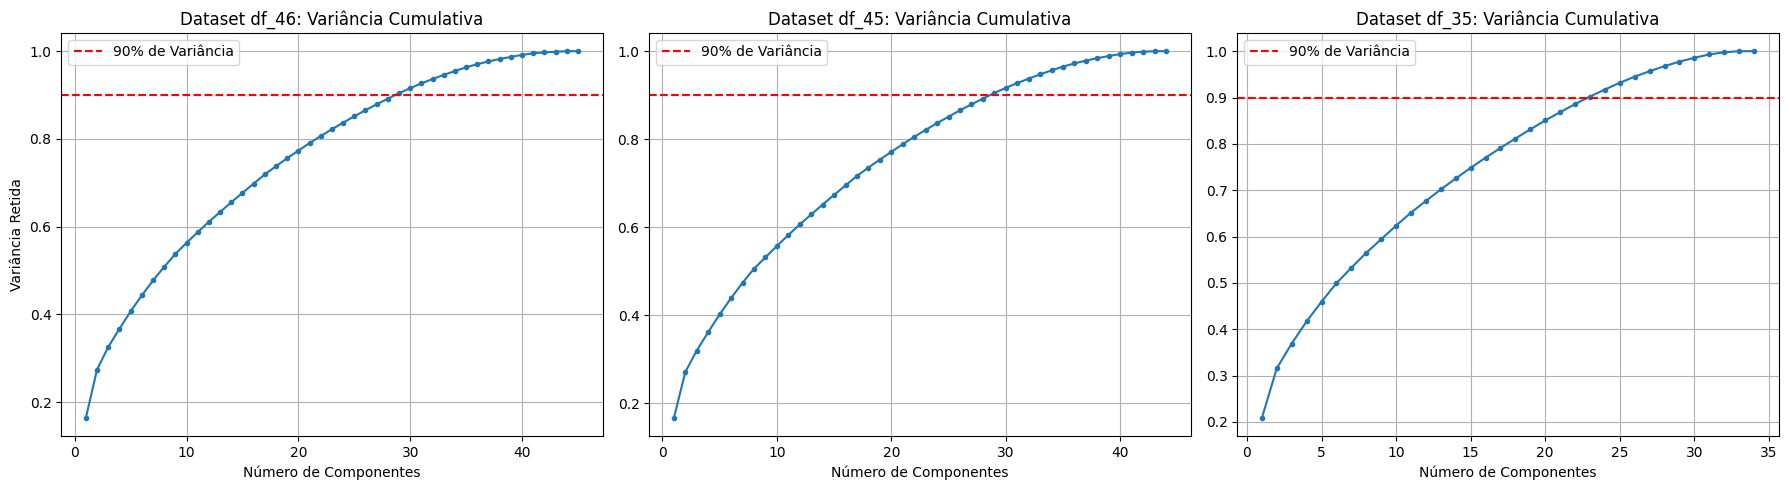

In [ ]:
# Cria uma figura com 1 linha e 3 colunas para os gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico para df_46
axes[0].plot(range(1, len(var_cumulativa_46) + 1), var_cumulativa_46, marker='.', linestyle='-')
axes[0].axhline(y=0.90, color='r', linestyle='--', label='90% de Variância')
axes[0].set_title('Dataset df_46: Variância Cumulativa')
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Variância Retida')
axes[0].legend()
axes[0].grid(True)

# Gráfico para df_45
axes[1].plot(range(1, len(var_cumulativa_45) + 1), var_cumulativa_45, marker='.', linestyle='-')
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% de Variância')
axes[1].set_title('Dataset df_45: Variância Cumulativa')
axes[1].set_xlabel('Número de Componentes')
axes[1].legend()
axes[1].grid(True)

# Gráfico para df_35
axes[2].plot(range(1, len(var_cumulativa_35) + 1), var_cumulativa_35, marker='.', linestyle='-')
axes[2].axhline(y=0.90, color='r', linestyle='--', label='90% de Variância')
axes[2].set_title('Dataset df_35: Variância Cumulativa')
axes[2].set_xlabel('Número de Componentes')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

Através dos gráficos de variância nós encontramos nossas dimensões ideais para cada dataset:

Dataset original: 30 componentes

Dataset reduzido: 25 componentes

Dataset 46: 29 componentes

Dataset 45: 29 componentes

Dataset 35: 23 componentes

Já é possível observar que os datasets 46 e 45 possuem o mesmo número de componentes, o que provavelmente significa que eles se tornaram redundantes. Iremos tirar a prova disso com nossos testes a seguir, mas primeiro, visualizaremos a distribuição dos nossos dados num gráfico 2D para ter uma ideia de como eles estão organizados no espaço, o que pode nos dizer se a escolha de algoritmos que fizemos foi boa.


No bloco abaixo, iremos visualizar nossos dados num plano 2D aplicando o PCA para observar a distribuição deles no espaço.

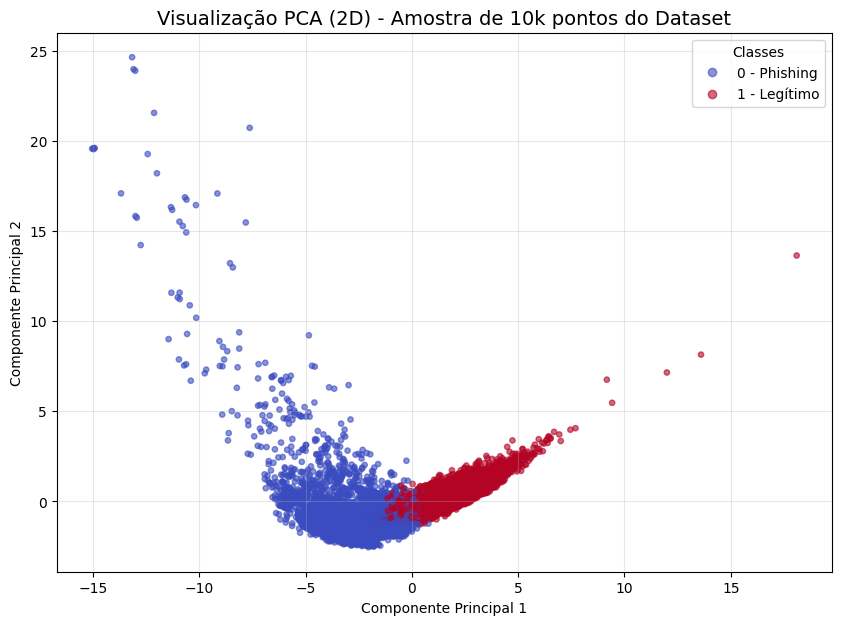

In [ ]:
# === Visualização 2D dos Dados ===

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_original_scaled)

# Pegando uma amostra de 10k pontos
np.random.seed(42)
amostra_indices = np.random.choice(len(X_pca_2d), size=10000, replace=False)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_2d[amostra_indices, 0],
                      X_pca_2d[amostra_indices, 1],
                      c=labels.iloc[amostra_indices], # Pinta com base se é 0 (Phishing) ou 1 (Legítimo)
                      cmap='coolwarm',
                      alpha=0.6,
                      s=15)

plt.title('Visualização PCA (2D) - Amostra de 10k pontos do Dataset', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Criando a legenda de cores
handles, _ = scatter.legend_elements()
plt.legend(handles, ['0 - Phishing', '1 - Legítimo'], title="Classes")

plt.grid(True, alpha=0.3)
plt.show()

O gráfico acima nos mostra que há uma delimitação clara entre clusters de URLs legitimas e de Phishing, com algum grau de ambiguidade entre as bordas, o que é perfeito para nosso algoritmo de K-Means. Entretanto, é possível ver também que a quantidade de URLs de Phishing é significantemente grande, formando um cluster de tamanho comparável às nossas URLs legítimas, o que é uma mal sinal para nosso modelo de Isolation Forest, já que há poucos outliers que corresponderão a URL de Phishing.

Podemos fazer uma previsão inicial, portanto, de que nosso algoritmo de K-Means capturará bem os dados e obterá resultados bons, mas o Isolation Forest provavelmente terá dificuldade em detectar URLs de Phishing.

Abaixo, aplicamos o PCA a cada um dos datasets com suas dimensionalidades adequadas.

Dados prontos para o K-Means: 235795 linhas e 25 colunas.



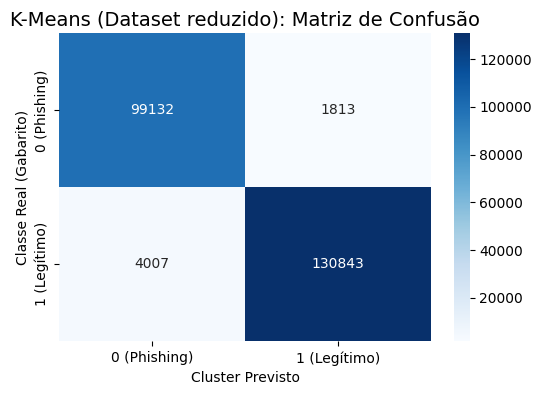


--- Relatório de Classificação do K-Means ---
              precision    recall  f1-score   support

0 (Phishing)       0.96      0.98      0.97    100945
1 (Legítimo)       0.99      0.97      0.98    134850

    accuracy                           0.98    235795
   macro avg       0.97      0.98      0.97    235795
weighted avg       0.98      0.98      0.98    235795



In [68]:
# === PCA com 25 ===
# Com os gráficos acima, concluímos que:
# 25 dimensões retêm ~90% da informação do dataset reduzido
pca_25 = PCA(n_components=25, random_state=42)
X_treino_kmeans = pca_25.fit_transform(X_reduzido_scaled)

print(f"Dados prontos para o K-Means: {X_treino_kmeans.shape[0]} linhas e {X_treino_kmeans.shape[1]} colunas.\n")

# Definimos k=2 porque sabemos que na realidade existem 2 classes (Phishing e Legítimo)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_brutos = kmeans.fit_predict(X_treino_kmeans)

# O K-Means não sabe o que é phishing. Ele apenas cria o "Grupo 0" e o "Grupo 1".
# Precisamos descobrir qual grupo tem a maioria de phishing (0) e qual tem a maioria de legítimos (1).

df_comparacao = pd.DataFrame({'Real': labels.values, 'Cluster': clusters_brutos})
matriz_cruzada = pd.crosstab(df_comparacao['Real'], df_comparacao['Cluster'])

mapeamento_clusters = {}
for cluster_id in matriz_cruzada.columns:
    # A classe real mais frequente dentro deste cluster define o que o cluster representa
    classe_predominante = matriz_cruzada[cluster_id].idxmax()
    mapeamento_clusters[cluster_id] = classe_predominante

# Substituímos os números arbitrários do K-Means pelos rótulos que fazem sentido
labels_kmeans = df_comparacao['Cluster'].map(mapeamento_clusters)

# Matriz de Confusão
cm = confusion_matrix(labels, labels_kmeans)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means (Dataset reduzido): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real (Gabarito)')
plt.xlabel('Cluster Previsto')
plt.show()

# Relatório de Métricas
print("\n--- Relatório de Classificação do K-Means ---")
print(classification_report(labels, labels_kmeans, target_names=['0 (Phishing)', '1 (Legítimo)']))

Dados originais prontos para o K-Means: 235795 linhas e 30 colunas.



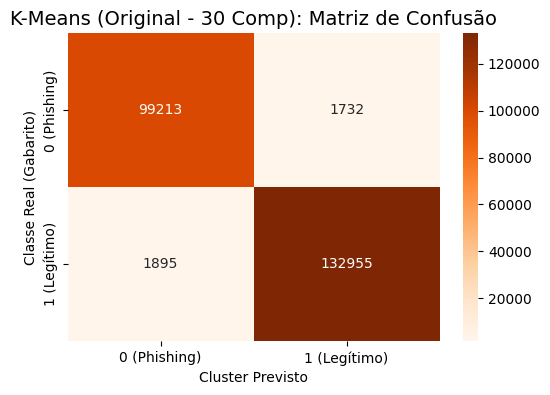


--- Relatório de Classificação (Original 30 Comp) ---
              precision    recall  f1-score   support

0 (Phishing)       0.98      0.98      0.98    100945
1 (Legítimo)       0.99      0.99      0.99    134850

    accuracy                           0.98    235795
   macro avg       0.98      0.98      0.98    235795
weighted avg       0.98      0.98      0.98    235795



In [ ]:
# === Preparação: PCA com 30 Componentes (Dataset Original) ===

pca_30_orig = PCA(n_components=30, random_state=42)
X_treino_kmeans_orig = pca_30_orig.fit_transform(X_original_scaled)

print(f"Dados originais prontos para o K-Means: {X_treino_kmeans_orig.shape[0]} linhas e {X_treino_kmeans_orig.shape[1]} colunas.\n")

kmeans_orig = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_brutos_orig = kmeans_orig.fit_predict(X_treino_kmeans_orig)

# Alinhamento de Rótulos (Cluster -> Classe Real)
df_comparacao_orig = pd.DataFrame({'Real': labels.values, 'Cluster': clusters_brutos_orig})
matriz_cruzada_orig = pd.crosstab(df_comparacao_orig['Real'], df_comparacao_orig['Cluster'])

mapeamento_clusters_orig = {}
for cluster_id in matriz_cruzada_orig.columns:
    classe_predominante = matriz_cruzada_orig[cluster_id].idxmax()
    mapeamento_clusters_orig[cluster_id] = classe_predominante

labels_kmeans_orig = df_comparacao_orig['Cluster'].map(mapeamento_clusters_orig)


# Avaliação de Performance
cm_orig = confusion_matrix(labels, labels_kmeans_orig)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means (Original - 30 Comp): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real (Gabarito)')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação (Original 30 Comp) ---")
print(classification_report(labels, labels_kmeans_orig, target_names=['0 (Phishing)', '1 (Legítimo)']))

Dataset 46 pronto para o K-Means: 235795 linhas e 29 colunas.



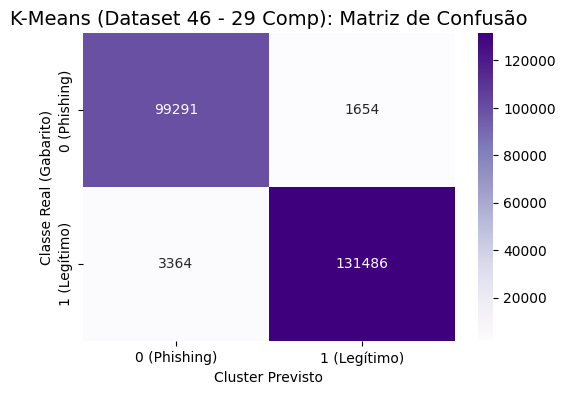


--- Relatório de Classificação (Dataset 46 - 29 Comp) ---
              precision    recall  f1-score   support

0 (Phishing)       0.97      0.98      0.98    100945
1 (Legítimo)       0.99      0.98      0.98    134850

    accuracy                           0.98    235795
   macro avg       0.98      0.98      0.98    235795
weighted avg       0.98      0.98      0.98    235795



In [ ]:
# === Preparação: PCA com 29 Componentes (Dataset 46) ===

pca_29_46 = PCA(n_components=29, random_state=42)
X_treino_kmeans_46 = pca_29_46.fit_transform(X_46_scaled)

print(f"Dataset 46 pronto para o K-Means: {X_treino_kmeans_46.shape[0]} linhas e {X_treino_kmeans_46.shape[1]} colunas.\n")

kmeans_46 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_brutos_46 = kmeans_46.fit_predict(X_treino_kmeans_46)

# Alinhamento de Rótulos (Cluster -> Classe Real)
df_comparacao_46 = pd.DataFrame({'Real': labels.values, 'Cluster': clusters_brutos_46})
matriz_cruzada_46 = pd.crosstab(df_comparacao_46['Real'], df_comparacao_46['Cluster'])

mapeamento_clusters_46 = {}
for cluster_id in matriz_cruzada_46.columns:
    classe_predominante = matriz_cruzada_46[cluster_id].idxmax()
    mapeamento_clusters_46[cluster_id] = classe_predominante

labels_kmeans_46 = df_comparacao_46['Cluster'].map(mapeamento_clusters_46)

# Avaliação de Performance
cm_46 = confusion_matrix(labels, labels_kmeans_46)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_46, annot=True, fmt='d', cmap='Purples',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means (Dataset 46 - 29 Comp): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real (Gabarito)')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação (Dataset 46 - 29 Comp) ---")
print(classification_report(labels, labels_kmeans_46, target_names=['0 (Phishing)', '1 (Legítimo)']))

Dataset 45 pronto para o K-Means: 235795 linhas e 29 colunas.



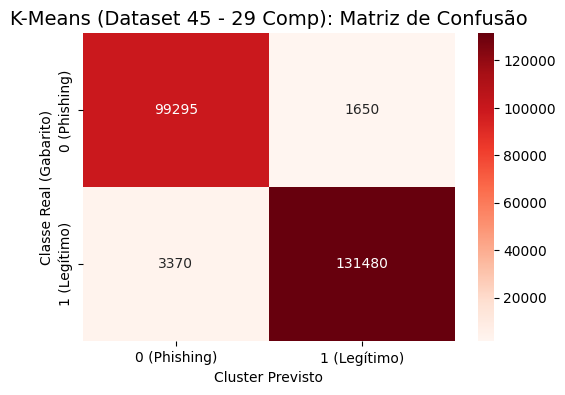


--- Relatório de Classificação (Dataset 45 - 29 Comp) ---
              precision    recall  f1-score   support

0 (Phishing)       0.97      0.98      0.98    100945
1 (Legítimo)       0.99      0.98      0.98    134850

    accuracy                           0.98    235795
   macro avg       0.98      0.98      0.98    235795
weighted avg       0.98      0.98      0.98    235795



In [ ]:
# === Preparação: PCA com 29 Componentes (Dataset 45) ===

pca_29_45 = PCA(n_components=29, random_state=42)
X_treino_kmeans_45 = pca_29_45.fit_transform(X_45_scaled)

print(f"Dataset 45 pronto para o K-Means: {X_treino_kmeans_45.shape[0]} linhas e {X_treino_kmeans_45.shape[1]} colunas.\n")

kmeans_45 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_brutos_45 = kmeans_45.fit_predict(X_treino_kmeans_45)

# Alinhamento de Rótulos (Cluster -> Classe Real)
df_comparacao_45 = pd.DataFrame({'Real': labels.values, 'Cluster': clusters_brutos_45})
matriz_cruzada_45 = pd.crosstab(df_comparacao_45['Real'], df_comparacao_45['Cluster'])

mapeamento_clusters_45 = {}
for cluster_id in matriz_cruzada_45.columns:
    classe_predominante = matriz_cruzada_45[cluster_id].idxmax()
    mapeamento_clusters_45[cluster_id] = classe_predominante

labels_kmeans_45 = df_comparacao_45['Cluster'].map(mapeamento_clusters_45)

# Avaliação de Performance
cm_45 = confusion_matrix(labels, labels_kmeans_45)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_45, annot=True, fmt='d', cmap='Reds',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means (Dataset 45 - 29 Comp): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real (Gabarito)')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação (Dataset 45 - 29 Comp) ---")
print(classification_report(labels, labels_kmeans_45, target_names=['0 (Phishing)', '1 (Legítimo)']))

Dataset 35 pronto para o K-Means: 235795 linhas e 23 colunas.



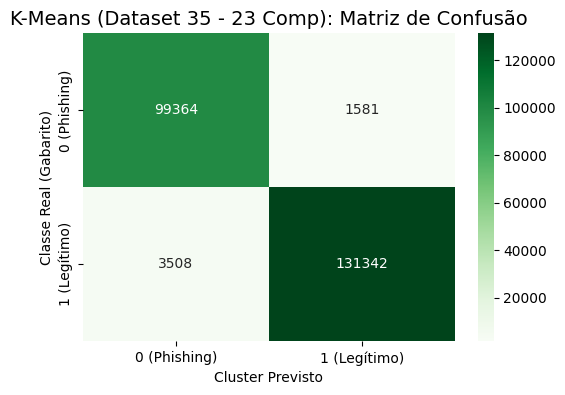


--- Relatório de Classificação (Dataset 35 - 23 Comp) ---
              precision    recall  f1-score   support

0 (Phishing)       0.97      0.98      0.98    100945
1 (Legítimo)       0.99      0.97      0.98    134850

    accuracy                           0.98    235795
   macro avg       0.98      0.98      0.98    235795
weighted avg       0.98      0.98      0.98    235795



In [ ]:
# === Preparação: PCA com 23 Componentes (Dataset 35) ===

pca_23_35 = PCA(n_components=23, random_state=42)
X_treino_kmeans_35 = pca_23_35.fit_transform(X_35_scaled)

print(f"Dataset 35 pronto para o K-Means: {X_treino_kmeans_35.shape[0]} linhas e {X_treino_kmeans_35.shape[1]} colunas.\n")

kmeans_35 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_brutos_35 = kmeans_35.fit_predict(X_treino_kmeans_35)

# Alinhamento de Rótulos (Cluster -> Classe Real)
df_comparacao_35 = pd.DataFrame({'Real': labels.values, 'Cluster': clusters_brutos_35})
matriz_cruzada_35 = pd.crosstab(df_comparacao_35['Real'], df_comparacao_35['Cluster'])

mapeamento_clusters_35 = {}
for cluster_id in matriz_cruzada_35.columns:
    classe_predominante = matriz_cruzada_35[cluster_id].idxmax()
    mapeamento_clusters_35[cluster_id] = classe_predominante

labels_kmeans_35 = df_comparacao_35['Cluster'].map(mapeamento_clusters_35)

# Avaliação de Performance
cm_35 = confusion_matrix(labels, labels_kmeans_35)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_35, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means (Dataset 35 - 23 Comp): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real (Gabarito)')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação (Dataset 35 - 23 Comp) ---")
print(classification_report(labels, labels_kmeans_35, target_names=['0 (Phishing)', '1 (Legítimo)']))

### Análise Exploratória de Clusterização (K-Means sem Train/Test Split)

Antes de construirmos o pipeline rigoroso de *Machine Learning*, optamos por executar o K-Means em todo o conjunto de dados, **sem aplicar a divisão de treino e teste (Train/Test Split)**.

Diferente de modelos supervisionados, o K-Means não "decora" as labels pois ele agrupa os dados baseando-se puramente na distância geométrica entre os pontos. Portanto, treinamos o algoritmo nos datasets completos e para comparar, no passo seguinte, se a separação entre treino e teste causará alguma diferença drástica.

#### **Análise e Comparação dos Resultados**

Avaliando os relatórios de classificação gerados, extraímos três grandes conclusões sobre o nosso problema e as diferentes versões do dataset:

**Alta Separabilidade Natural**
O resultado mais promissor é que todas as versões do dataset alcançaram uma acurácia excelente de **98%**. Isso prova que as URLs de *phishing* neste dataset não estão sutilmente misturadas com as legítimas, elas possuem estruturas muito distintas no espaço vetorial criado pelo PCA. O K-Means conseguiu "enxergar" o que é phishing quase perfeitamente sem nunca ter visto as labels.

**Comparação de datasets**
* **Reduzido:** Obteve uma precisão de 0.96 e recall de 0.98 para *phishing*.
* **Original (30 Componentes):** Alcançou precisão de 0.98 e recall de 0.98 para *phishing*.
Embora o grupo tenha feito um ótimo trabalho ao remover 16 colunas e manter o desempenho quase intacto, o Dataset Original teve uma precisão ligeiramente superior (gerou menos falsos positivos). Isso indica que, no corte do pré-processamento, algumas daquelas 16 variáveis continham nuances sutis que auxiliavam na delimitação matemática das fronteiras entre os clusters, embora o custo-benefício de usar o Reduzido (modelo mais leve e menos propenso a overfitting) ainda pareça muito vantajoso.

* **Dataset 46 (29 Componentes):** Precisão 0.97, Recall 0.98, F1-Score 0.98 || **Dataset 45 (29 Componentes):** Precisão 0.97, Recall 0.98, F1-Score 0.98.
Conforme suspeitávamos ao observar os gráficos de variância, os resultados preditivos confirmam a nossa hipótese de que os datasets 46 e 45 são funcionalmente idênticos para modelos não-supervisionados. O fato de o PCA estabilizar em 29 componentes para ambos e o K-Means retornar métricas cravadas e rigorosamente iguais prova que a variável descartada na transição do dataset 46 para o 45 era completamente redundante ou irrelevante, não agregando nenhum poder discriminatório ao modelo.

* **Dataset 35 (23 Componentes):** Precisão 0.97, Recall 0.98, F1-Score 0.98.
O desempenho do Dataset 35 foi equivalente às versões com 46 e 45 colunas, mantendo uma impressionante acurácia global de 98%. A única diferença estatística foi uma variação muito pequena no *recall* da classe legítima (que oscilou de 0.98 para 0.97), um impacto irrisório. A grande vitória desta versão é o custo-benefício computacional: conseguimos comprimir a informação para apenas 23 componentes principais (a versão mais leve de todas) sem degradar o altíssimo poder discriminatório do modelo. Isso prova que o dataset original possuía muito ruído e que o K-Means consegue operar de forma extremamente eficiente num espaço dimensional bem menor.

Tamanho do Treino: 165056 linhas
Tamanho do Teste: 70739 linhas



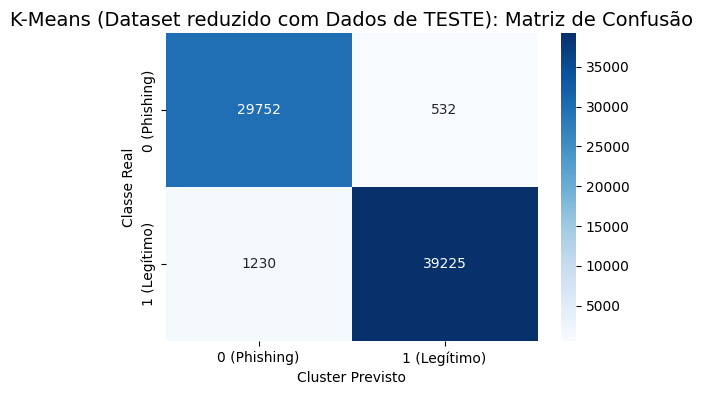


--- Relatório de Classificação K-Means (DADOS DE TESTE) ---
              precision    recall  f1-score   support

0 (Phishing)       0.96      0.98      0.97     30284
1 (Legítimo)       0.99      0.97      0.98     40455

    accuracy                           0.98     70739
   macro avg       0.97      0.98      0.97     70739
weighted avg       0.98      0.98      0.98     70739



In [ ]:
from sklearn.model_selection import train_test_split

# === Divisão dos Dados (Train/Test Split) ===
# Vimos como o K-Means funciona usando o dataset inteiro
# Agora, vamos separar 30% dos dados para teste e 70% para treino e comparar os resultados.
# O parâmetro stratify=labels garante que a proporção de phishing/legítimo seja igual no treino e no teste.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_reduzido_num, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Tamanho do Treino: {X_train_raw.shape[0]} linhas")
print(f"Tamanho do Teste: {X_test_raw.shape[0]} linhas\n")

# Padronização e PCA
scaler_definitivo = StandardScaler()
pca_definitivo = PCA(n_components=25, random_state=42)

# FIT apenas no treino. Transform no treino e no teste.
X_train_scaled = scaler_definitivo.fit_transform(X_train_raw)
X_test_scaled = scaler_definitivo.transform(X_test_raw)

# FIT do PCA apenas no treino.
X_train_pca = pca_definitivo.fit_transform(X_train_scaled)
X_test_pca = pca_definitivo.transform(X_test_scaled)

# Treinando o K-Means
kmeans_definitivo = KMeans(n_clusters=2, random_state=42, n_init=10)

# O K-Means aprende os clusters usando apenas os dados de treino
clusters_train = kmeans_definitivo.fit_predict(X_train_pca)

# Alinhamento de Rótulos
# Descobrimos qual cluster é phishing e qual é legítimo olhando apenas para o treino
df_train_comparacao = pd.DataFrame({'Real': y_train.values, 'Cluster': clusters_train})
matriz_cruzada_train = pd.crosstab(df_train_comparacao['Real'], df_train_comparacao['Cluster'])

mapeamento = {}
for cluster_id in matriz_cruzada_train.columns:
    mapeamento[cluster_id] = matriz_cruzada_train[cluster_id].idxmax()

# Avaliando nos dados de teste
# Pedimos ao K-Means para classificar os dados inéditos de teste
clusters_test_brutos = kmeans_definitivo.predict(X_test_pca)

# Mapeamos os números dos clusters para os rótulos reais (0 ou 1)
y_pred_test_kmeans = pd.Series(clusters_test_brutos).map(mapeamento)

# Métricas Finais do K-Means
cm_test = confusion_matrix(y_test, y_pred_test_kmeans)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means (Dataset reduzido com Dados de TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação K-Means (DADOS DE TESTE) ---")
print(classification_report(y_test, y_pred_test_kmeans, target_names=['0 (Phishing)', '1 (Legítimo)']))

Tamanho do Treino (Original): 165056 linhas
Tamanho do Teste (Original): 70739 linhas



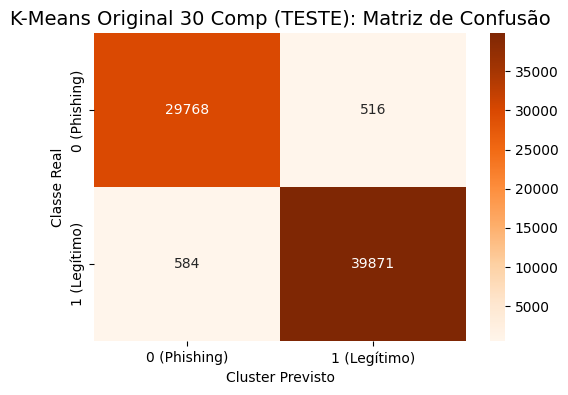


--- Relatório de Classificação K-Means Original (DADOS DE TESTE) ---
              precision    recall  f1-score   support

0 (Phishing)       0.98      0.98      0.98     30284
1 (Legítimo)       0.99      0.99      0.99     40455

    accuracy                           0.98     70739
   macro avg       0.98      0.98      0.98     70739
weighted avg       0.98      0.98      0.98     70739



In [ ]:
# Faremos o mesmo que fizemos acima, mas usando o df_original_num que tem 50 colunas para propósitos comparativos
X_train_orig_raw, X_test_orig_raw, y_train_orig, y_test_orig = train_test_split(
    df_original_num, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Tamanho do Treino (Original): {X_train_orig_raw.shape[0]} linhas")
print(f"Tamanho do Teste (Original): {X_test_orig_raw.shape[0]} linhas\n")

scaler_orig_def = StandardScaler()
pca_orig_def = PCA(n_components=30, random_state=42)

X_train_orig_scaled = scaler_orig_def.fit_transform(X_train_orig_raw)
X_test_orig_scaled = scaler_orig_def.transform(X_test_orig_raw)

X_train_orig_pca = pca_orig_def.fit_transform(X_train_orig_scaled)
X_test_orig_pca = pca_orig_def.transform(X_test_orig_scaled)

kmeans_orig_def = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_train_orig = kmeans_orig_def.fit_predict(X_train_orig_pca)

df_train_comp_orig = pd.DataFrame({'Real': y_train_orig.values, 'Cluster': clusters_train_orig})
matriz_cruzada_orig = pd.crosstab(df_train_comp_orig['Real'], df_train_comp_orig['Cluster'])

mapeamento_orig = {}
for cluster_id in matriz_cruzada_orig.columns:
    mapeamento_orig[cluster_id] = matriz_cruzada_orig[cluster_id].idxmax()

# Avaliação
clusters_test_orig_brutos = kmeans_orig_def.predict(X_test_orig_pca)
y_pred_test_kmeans_orig = pd.Series(clusters_test_orig_brutos).map(mapeamento_orig)

# Métricas Finais
cm_test_orig = confusion_matrix(y_test_orig, y_pred_test_kmeans_orig)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_orig, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means Original 30 Comp (TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação K-Means Original (DADOS DE TESTE) ---")
print(classification_report(y_test_orig, y_pred_test_kmeans_orig, target_names=['0 (Phishing)', '1 (Legítimo)']))

Tamanho do Treino (Dataset 46): 165056 linhas
Tamanho do Teste (Dataset 46): 70739 linhas



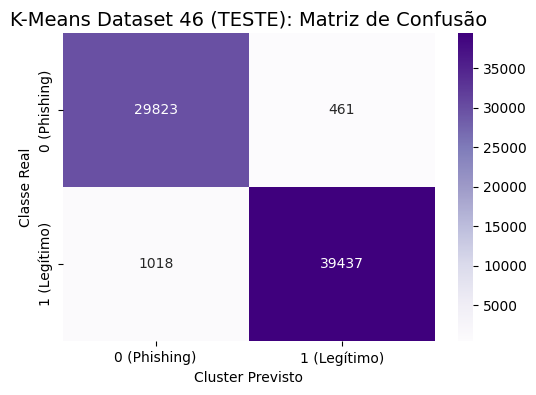


--- Relatório de Classificação K-Means Dataset 46 (DADOS DE TESTE) ---
              precision    recall  f1-score   support

0 (Phishing)       0.97      0.98      0.98     30284
1 (Legítimo)       0.99      0.97      0.98     40455

    accuracy                           0.98     70739
   macro avg       0.98      0.98      0.98     70739
weighted avg       0.98      0.98      0.98     70739



In [ ]:
# K-Means com Train/Test Split: Dataset 46 (29 Componentes)

X_train_46_raw, X_test_46_raw, y_train_46, y_test_46 = train_test_split(
    df_46_num, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Tamanho do Treino (Dataset 46): {X_train_46_raw.shape[0]} linhas")
print(f"Tamanho do Teste (Dataset 46): {X_test_46_raw.shape[0]} linhas\n")

scaler_46_def = StandardScaler()
pca_46_def = PCA(n_components=29, random_state=42)

X_train_46_scaled = scaler_46_def.fit_transform(X_train_46_raw)
X_test_46_scaled = scaler_46_def.transform(X_test_46_raw)

X_train_46_pca = pca_46_def.fit_transform(X_train_46_scaled)
X_test_46_pca = pca_46_def.transform(X_test_46_scaled)

kmeans_46_def = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_train_46 = kmeans_46_def.fit_predict(X_train_46_pca)

df_train_comp_46 = pd.DataFrame({'Real': y_train_46.values, 'Cluster': clusters_train_46})
matriz_cruzada_46 = pd.crosstab(df_train_comp_46['Real'], df_train_comp_46['Cluster'])

mapeamento_46 = {}
for cluster_id in matriz_cruzada_46.columns:
    mapeamento_46[cluster_id] = matriz_cruzada_46[cluster_id].idxmax()

# Avaliação
clusters_test_46_brutos = kmeans_46_def.predict(X_test_46_pca)
y_pred_test_kmeans_46 = pd.Series(clusters_test_46_brutos).map(mapeamento_46)

# Métricas Finais
cm_test_46 = confusion_matrix(y_test_46, y_pred_test_kmeans_46)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_46, annot=True, fmt='d', cmap='Purples',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means Dataset 46 (TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação K-Means Dataset 46 (DADOS DE TESTE) ---")
print(classification_report(y_test_46, y_pred_test_kmeans_46, target_names=['0 (Phishing)', '1 (Legítimo)']))

Tamanho do Treino (Dataset 46): 165056 linhas
Tamanho do Teste (Dataset 46): 70739 linhas



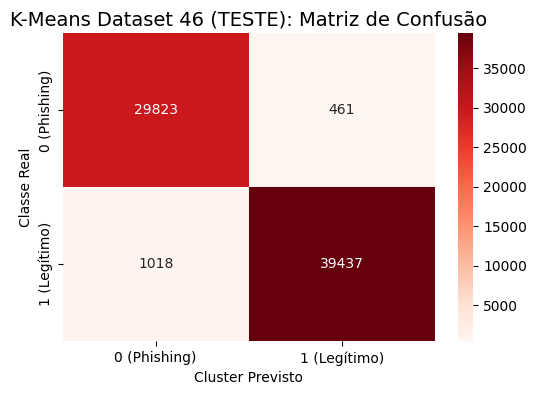


--- Relatório de Classificação K-Means Dataset 46 (DADOS DE TESTE) ---
              precision    recall  f1-score   support

0 (Phishing)       0.97      0.98      0.98     30284
1 (Legítimo)       0.99      0.97      0.98     40455

    accuracy                           0.98     70739
   macro avg       0.98      0.98      0.98     70739
weighted avg       0.98      0.98      0.98     70739



In [ ]:
# Dataset 46 (29 Componentes)

X_train_46_raw, X_test_46_raw, y_train_46, y_test_46 = train_test_split(
    df_46_num, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Tamanho do Treino (Dataset 46): {X_train_46_raw.shape[0]} linhas")
print(f"Tamanho do Teste (Dataset 46): {X_test_46_raw.shape[0]} linhas\n")

scaler_46_def = StandardScaler()
pca_46_def = PCA(n_components=29, random_state=42)

X_train_46_scaled = scaler_46_def.fit_transform(X_train_46_raw)
X_test_46_scaled = scaler_46_def.transform(X_test_46_raw)

X_train_46_pca = pca_46_def.fit_transform(X_train_46_scaled)
X_test_46_pca = pca_46_def.transform(X_test_46_scaled)

kmeans_46_def = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_train_46 = kmeans_46_def.fit_predict(X_train_46_pca)

df_train_comp_46 = pd.DataFrame({'Real': y_train_46.values, 'Cluster': clusters_train_46})
matriz_cruzada_46 = pd.crosstab(df_train_comp_46['Real'], df_train_comp_46['Cluster'])

mapeamento_46 = {}
for cluster_id in matriz_cruzada_46.columns:
    mapeamento_46[cluster_id] = matriz_cruzada_46[cluster_id].idxmax()

# Avaliação
clusters_test_46_brutos = kmeans_46_def.predict(X_test_46_pca)
y_pred_test_kmeans_46 = pd.Series(clusters_test_46_brutos).map(mapeamento_46)

# Métricas Finais
cm_test_46 = confusion_matrix(y_test_46, y_pred_test_kmeans_46)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_46, annot=True, fmt='d', cmap='Reds',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means Dataset 46 (TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação K-Means Dataset 46 (DADOS DE TESTE) ---")
print(classification_report(y_test_46, y_pred_test_kmeans_46, target_names=['0 (Phishing)', '1 (Legítimo)']))

Tamanho do Treino (Dataset 35): 165056 linhas
Tamanho do Teste (Dataset 35): 70739 linhas



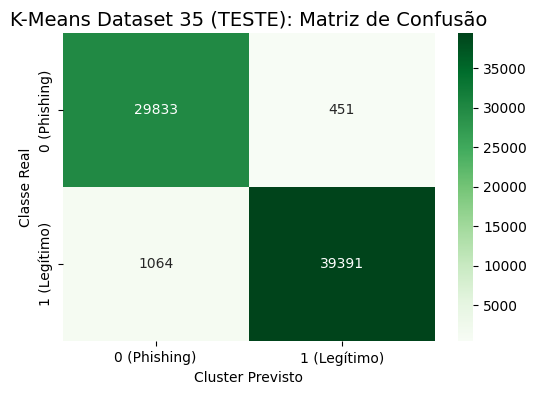


--- Relatório de Classificação K-Means Dataset 35 (DADOS DE TESTE) ---
              precision    recall  f1-score   support

0 (Phishing)       0.97      0.99      0.98     30284
1 (Legítimo)       0.99      0.97      0.98     40455

    accuracy                           0.98     70739
   macro avg       0.98      0.98      0.98     70739
weighted avg       0.98      0.98      0.98     70739



In [ ]:
# Dataset 35 (23 Componentes)

X_train_35_raw, X_test_35_raw, y_train_35, y_test_35 = train_test_split(
    df_35_num, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Tamanho do Treino (Dataset 35): {X_train_35_raw.shape[0]} linhas")
print(f"Tamanho do Teste (Dataset 35): {X_test_35_raw.shape[0]} linhas\n")

scaler_35_def = StandardScaler()
pca_35_def = PCA(n_components=23, random_state=42)

X_train_35_scaled = scaler_35_def.fit_transform(X_train_35_raw)
X_test_35_scaled = scaler_35_def.transform(X_test_35_raw)

X_train_35_pca = pca_35_def.fit_transform(X_train_35_scaled)
X_test_35_pca = pca_35_def.transform(X_test_35_scaled)

kmeans_35_def = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_train_35 = kmeans_35_def.fit_predict(X_train_35_pca)

df_train_comp_35 = pd.DataFrame({'Real': y_train_35.values, 'Cluster': clusters_train_35})
matriz_cruzada_35 = pd.crosstab(df_train_comp_35['Real'], df_train_comp_35['Cluster'])

mapeamento_35 = {}
for cluster_id in matriz_cruzada_35.columns:
    mapeamento_35[cluster_id] = matriz_cruzada_35[cluster_id].idxmax()

# Avaliação
clusters_test_35_brutos = kmeans_35_def.predict(X_test_35_pca)
y_pred_test_kmeans_35 = pd.Series(clusters_test_35_brutos).map(mapeamento_35)

# Métricas Finais
cm_test_35 = confusion_matrix(y_test_35, y_pred_test_kmeans_35)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_35, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('K-Means Dataset 35 (TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Cluster Previsto')
plt.show()

print("\n--- Relatório de Classificação K-Means Dataset 35 (DADOS DE TESTE) ---")
print(classification_report(y_test_35, y_pred_test_kmeans_35, target_names=['0 (Phishing)', '1 (Legítimo)']))

### Validação do Modelo: K-Means com Train/Test Split (70/30)

Após a análise exploratória, implementamos a separação rigorosa dos dados em 70% para treino e 30% para teste. Nesta etapa aplica o escalonamento (`StandardScaler`) e a redução de dimensionalidade (`PCA`) são treinados (*fit*) **exclusivamente nos dados de treino**, evitando qualquer vazamento de informação. O algoritmo K-Means gerou os clusters apenas com o treino e, em seguida, pedimos para ele classificar as instâncias inéditas de teste.

#### Comparação entre os Datasets

Avaliar o modelo em dados que ele nunca viu revela a sua verdadeira capacidade de generalização. Ao compararmos os recortes do dataset, observamos:

* Todas as versões do dataset sustentaram uma acurácia global de **98%** nos dados de teste. A separabilidade geométrica entre *phishing* e sites legítimos é ótima.
* O Dataset Original continuou superior na precisão para detectar *phishing* (0.98 contra 0.96 do Reduzido) e legítimos (0.99 contra 0.99). Isso reitera que algumas variáveis descartadas na limpeza inicial continham traços sutis de diferenciação, embora o Reduzido ainda entregue uma performance muito boa. Novamente confirmamos que métricas de teste dos datasets de 45 e 46 cravaram exatamente os mesmos resultados (Precisão 0.97, Recall 0.98). Já que se tratam de datasets essencialmente equivalentes, ficaremos só com o dataset 46 daqui em diante.
* O Dataset 35, com apenas 23 componentes, apresentou um comportamento excelente. Ele não apenas manteve a acurácia de 98%, como elevou o *recall* da classe de phishing para 0.99. Em cibersegurança, o *recall* da classe de ataque é frequentemente a métrica mais importante, pois minimizar "falsos negativos" (deixar um phishing passar direto) é o objetivo principal. Obter esse nível de segurança com o modelo matematicamente mais leve de todos é o cenário ideal.

#### Comparação com o Cenário Exploratório (Sem Split vs. Com Split)

Com essa etapa, quando comparamos estes resultados do Teste com os resultados do modelo exploratório, concluimos que os resultados são virtualmente idênticos. As oscilações não passaram de 0.01 ponto no *recall* ou *f1-score*.

Esta estabilidade matemática prova duas coisas para o nosso trabalho:
1. **Ausência de Overfitting:** O K-Means não havia "decorado" a distribuição geral dos dados no passo anterior. Os agrupamentos descobertos por ele são padrões universais do problema.
2. **Ausência de Vazamento de Dados:** As transformações do PCA e do Scaler generalizaram perfeitamente.

Em suma, a técnica de aprendizado não-supervisionado provou, com rigor de validação cruzada, que o problema de *phishing* neste conjunto de dados possui uma fronteira geométrica bem definida na maioria dos casos, e que o K-Means é um excelente modelo para atacar este problema.


Abaixo, agora, vamos ver como o modelo de Isolation Forest performa com os nossos datasets.

Taxa de contaminação (Phishing) detectada: 0.4281 (42.81%)



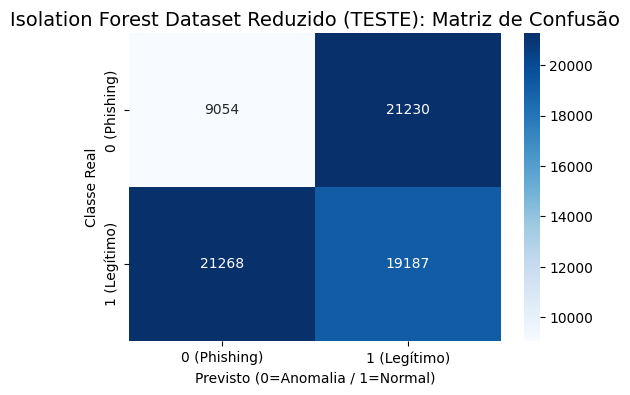


--- Relatório de Classificação Isolation Forest (DADOS DE TESTE) ---
              precision    recall  f1-score   support

0 (Phishing)       0.30      0.30      0.30     30284
1 (Legítimo)       0.47      0.47      0.47     40455

    accuracy                           0.40     70739
   macro avg       0.39      0.39      0.39     70739
weighted avg       0.40      0.40      0.40     70739



In [ ]:
# === ISOLATION FOREST ===

# Definindo a proporção de Anomalias (Phishing)
# Calculamos a porcentagem exata de phishing nos dados de treino
proporcao_phishing = (y_train == 0).sum() / len(y_train)
print(f"Taxa de contaminação (Phishing) detectada: {proporcao_phishing:.4f} ({proporcao_phishing*100:.2f}%)\n")

# Treinando a Isolation Forest
# Instanciamos o modelo. Usamos os dados escalonados (X_train_scaled) sem PCA!
iso_forest = IsolationForest(contamination=proporcao_phishing, random_state=42, n_jobs=-1)

# A floresta aprende o que é "normal" e o que é "anomalo" apenas com o treino
iso_forest.fit(X_train_scaled)

# Previsão nos Dados de Teste
preds_test_if = iso_forest.predict(X_test_scaled)

# O Isolation Forest retorna uma nomenclatura diferente:
#  1 = Inliers (Dados Normais -> No nosso caso, Legítimo -> Label 1)
# -1 = Outliers (Anomalias -> No nosso caso, Phishing -> Label 0)

# Vamos mapear o -1 para 0 para conseguirmos comparar com nosso gabarito (y_test)
import numpy as np
y_pred_test_if = np.where(preds_test_if == -1, 0, 1)

# Avaliando
cm_if = confusion_matrix(y_test, y_pred_test_if)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('Isolation Forest Dataset Reduzido (TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Previsto (0=Anomalia / 1=Normal)')
plt.show()

print("\n--- Relatório de Classificação Isolation Forest (DADOS DE TESTE) ---")
print(classification_report(y_test, y_pred_test_if, target_names=['0 (Phishing)', '1 (Legítimo)']))

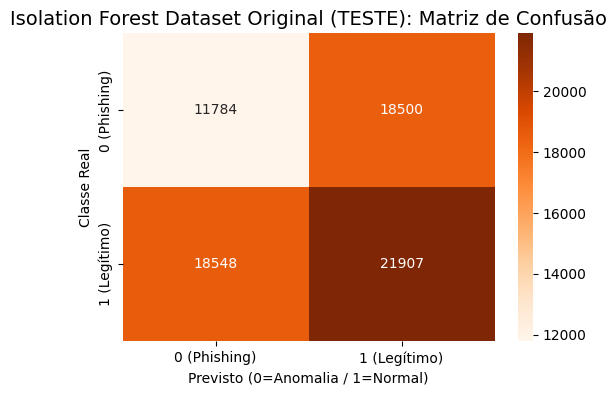


--- Relatório de Classificação Isolation Forest Dataset ORIGINAL (DADOS DE TESTE) ---
              precision    recall  f1-score   support

0 (Phishing)       0.39      0.39      0.39     30284
1 (Legítimo)       0.54      0.54      0.54     40455

    accuracy                           0.48     70739
   macro avg       0.47      0.47      0.47     70739
weighted avg       0.48      0.48      0.48     70739



In [ ]:
# Usando o dataset original
proporcao_phishing_orig = (y_train_orig == 0).sum() / len(y_train_orig)

# Usamos X_train_orig_scaled (50 colunas, sem PCA)
iso_forest_orig = IsolationForest(contamination=proporcao_phishing_orig, random_state=42, n_jobs=-1)
iso_forest_orig.fit(X_train_orig_scaled)

# Previsão
preds_test_if_orig = iso_forest_orig.predict(X_test_orig_scaled)

# Mapeando: -1 (Anomalia) -> 0 (Phishing) | 1 (Normal) -> 1 (Legítimo)
y_pred_test_if_orig = np.where(preds_test_if_orig == -1, 0, 1)

# Avaliação
cm_if_orig = confusion_matrix(y_test_orig, y_pred_test_if_orig)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_if_orig, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('Isolation Forest Dataset Original (TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Previsto (0=Anomalia / 1=Normal)')
plt.show()

print("\n--- Relatório de Classificação Isolation Forest Dataset ORIGINAL (DADOS DE TESTE) ---")
print(classification_report(y_test_orig, y_pred_test_if_orig, target_names=['0 (Phishing)', '1 (Legítimo)']))

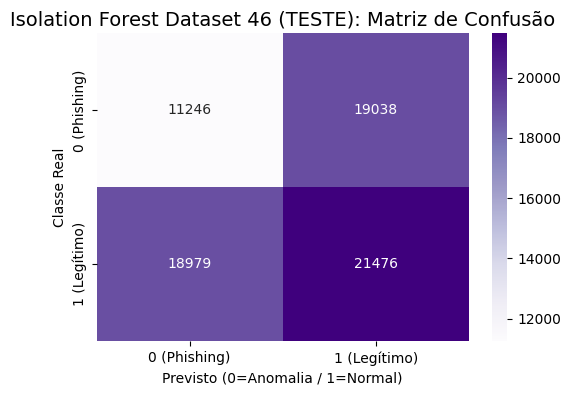


--- Relatório de Classificação Isolation Forest DATASET 46 ---
              precision    recall  f1-score   support

0 (Phishing)       0.37      0.37      0.37     30284
1 (Legítimo)       0.53      0.53      0.53     40455

    accuracy                           0.46     70739
   macro avg       0.45      0.45      0.45     70739
weighted avg       0.46      0.46      0.46     70739



In [ ]:

# Usando Dataset 46

proporcao_phishing_46 = (y_train_46 == 0).sum() / len(y_train_46)
iso_forest_46 = IsolationForest(contamination=proporcao_phishing_46, random_state=42, n_jobs=-1)
iso_forest_46.fit(X_train_46_scaled)
preds_test_if_46 = iso_forest_46.predict(X_test_46_scaled)
y_pred_test_if_46 = np.where(preds_test_if_46 == -1, 0, 1)
cm_if_46 = confusion_matrix(y_test_46, y_pred_test_if_46)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_if_46, annot=True, fmt='d', cmap='Purples',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('Isolation Forest Dataset 46 (TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Previsto (0=Anomalia / 1=Normal)')
plt.show()

print("\n--- Relatório de Classificação Isolation Forest DATASET 46 ---")
print(classification_report(y_test_46, y_pred_test_if_46, target_names=['0 (Phishing)', '1 (Legítimo)']))

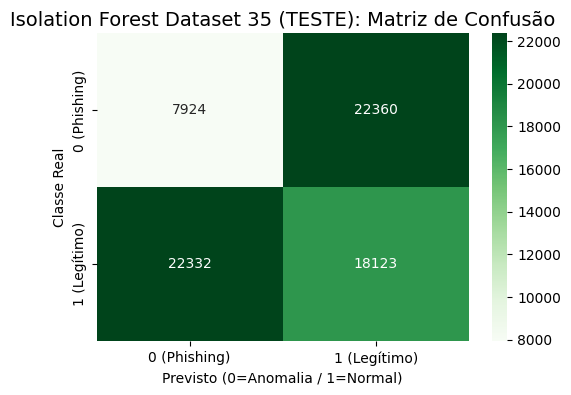


--- Relatório de Classificação Isolation Forest DATASET 35 ---
              precision    recall  f1-score   support

0 (Phishing)       0.26      0.26      0.26     30284
1 (Legítimo)       0.45      0.45      0.45     40455

    accuracy                           0.37     70739
   macro avg       0.35      0.35      0.35     70739
weighted avg       0.37      0.37      0.37     70739



In [ ]:
# Usando Dataset 35

proporcao_phishing_35 = (y_train_35 == 0).sum() / len(y_train_35)

iso_forest_35 = IsolationForest(contamination=proporcao_phishing_35, random_state=42, n_jobs=-1)
iso_forest_35.fit(X_train_35_scaled)

preds_test_if_35 = iso_forest_35.predict(X_test_35_scaled)

y_pred_test_if_35 = np.where(preds_test_if_35 == -1, 0, 1)

cm_if_35 = confusion_matrix(y_test_35, y_pred_test_if_35)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_if_35, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('Isolation Forest Dataset 35 (TESTE): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Previsto (0=Anomalia / 1=Normal)')
plt.show()

print("\n--- Relatório de Classificação Isolation Forest DATASET 35 ---")
print(classification_report(y_test_35, y_pred_test_if_35, target_names=['0 (Phishing)', '1 (Legítimo)']))

### Avaliação de Detecção de Anomalias: Isolation Forest

Para contrastar com a abordagem geométrica do K-Means, implementamos a **Isolation Forest**, um modelo baseado em árvores projetado especificamente para a detecção de outliers. O algoritmo funciona sob a premissa de que anomalias são instâncias "poucas e diferentes", o que significa que elas podem ser isoladas do resto dos dados com poucos cortes nas árvores.

Para este teste, utilizamos os dados escalonados em seus eixos originais (sem a rotação do PCA), ajustando a taxa de contaminação para refletir a proporção exata de phishing nos dados de treino (~42.8%).

#### Análise Geral dos Resultados

Ao contrário do enorme sucesso do K-Means, a Isolation Forest apresentou um desempenho extremamente ruim em todas as versões do dataset. As acurácias variaram entre 37% e 48%, indicando que o modelo operou com uma taxa de acerto pior do que a de uma escolha aleatória.

Essa falha não representa um erro de código ou de pré-processamento, mas sim uma descoberta sobre a natureza do nosso problema:

Phishing não é raro em nosso dataset. Com quase 43% de representatividade no dataset, os sites falsos formam uma classe densa e robusta, quebrando a premissa de que anomalias devem ser instâncias escassas. O objetivo central de uma URL de *phishing* é imitar com perfeição um site legítimo. Portanto, seus atributos não são isolados no espaço de dados.

#### Comparação do Desempenho entre os Datasets

Embora todos os resultados tenham sido fracos, observou-se uma tendência nas árvores de isolamento:

* **Original (48% de acurácia):** Foi o modelo "menos pior", conseguindo 0.39 de *recall* para phishing.
* **Dataset 46 (46% de acurácia):** Apresentou uma leve queda em relação ao original, com 0.37 de *recall*.
* **Dataset Reduzido (40% de acurácia):** O desempenho continuou caindo substancialmente, com 0.30 de *recall*.
* **Dataset 35 (37% de acurácia):** O pior cenário, identificando apenas 26% dos sites de *phishing*.

Isso nos diz que existe uma relação direta entre a remoção de *features* e a piora da Isolation Forest. Ao simplificarmos o dataset nós removemos ruídos, mas também removemos as poucas "arestas" ou atributos esquisitos que alguns sites de *phishing* possuíam e que permitiam que eles fossem isolados como anomalias. Quanto mais enxuto o dataset ficou, mais perfeitos e parecidos com sites legítimos os registros de *phishing* pareceram para as árvores de isolamento.

#### Conclusão

A discrepância brutal de performance entre o K-Means (98%) e a Isolation Forest (< 50%) encerra a nossa etapa não-supervisionada com uma conclusão sólida: O *phishing* neste domínio não pode ser tratado como um outlier estatístico, mas sim como um agrupamento denso com uma fronteira geométrica bem definida. Este resultado justifica perfeitamente usar o **Dataset 35** para o K-Means numa aplicação real. Para os modelos supervisionados (como Random Forest e XGBoost) na próxima etapa do trabalho isso também nos dá boas métricas do que esperar.

Ainda assim, para propósitos puramente analíticos, iremos rodar o isolation forest com auxílio do PCA a seguir para constar se sua aplicabilidade melhora, piora ou se mantém a mesma.

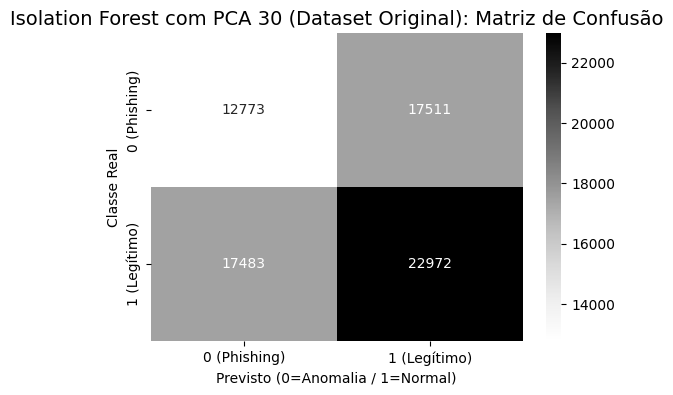


--- Relatório de Classificação Isolation Forest com PCA 30 ---
              precision    recall  f1-score   support

0 (Phishing)       0.42      0.42      0.42     30284
1 (Legítimo)       0.57      0.57      0.57     40455

    accuracy                           0.51     70739
   macro avg       0.49      0.49      0.49     70739
weighted avg       0.51      0.51      0.51     70739



In [ ]:
# Treinamento da Isolation Forest (PCA 30)
# Para fins comparativos, vamos rodar o isolation forest uma vez com PCA do dataset original
# Provavelmente oferecerá resultados tão ruins quanto os anteriores.
iso_forest_pca = IsolationForest(contamination=proporcao_phishing_orig, random_state=42, n_jobs=-1)
iso_forest_pca.fit(X_train_orig_pca)

# Previsão nos Dados de Teste
preds_test_if_pca = iso_forest_pca.predict(X_test_orig_pca)

# Mapeando: -1 (Anomalia) -> 0 (Phishing) | 1 (Normal) -> 1 (Legítimo)
y_pred_test_if_pca = np.where(preds_test_if_pca == -1, 0, 1)

# Avaliação
cm_if_pca = confusion_matrix(y_test_orig, y_pred_test_if_pca)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_if_pca, annot=True, fmt='d', cmap='Greys',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('Isolation Forest com PCA 30 (Dataset Original): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Previsto (0=Anomalia / 1=Normal)')
plt.show()

print("\n--- Relatório de Classificação Isolation Forest com PCA 30 ---")
print(classification_report(y_test_orig, y_pred_test_if_pca, target_names=['0 (Phishing)', '1 (Legítimo)']))

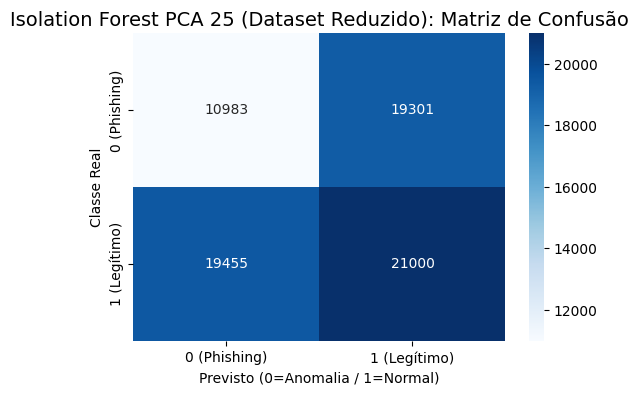


--- Relatório de Classificação Isolation Forest com PCA 25 (Dataset Reduzido) ---
              precision    recall  f1-score   support

0 (Phishing)       0.36      0.36      0.36     30284
1 (Legítimo)       0.52      0.52      0.52     40455

    accuracy                           0.45     70739
   macro avg       0.44      0.44      0.44     70739
weighted avg       0.45      0.45      0.45     70739



In [ ]:
# Isolation Forest com PCA 25: Dataset Reduzido

proporcao_phishing_red = (y_train == 0).sum() / len(y_train)

iso_forest_pca_red = IsolationForest(contamination=proporcao_phishing_red, random_state=42, n_jobs=-1)
iso_forest_pca_red.fit(X_train_pca)

preds_test_if_pca_red = iso_forest_pca_red.predict(X_test_pca)

y_pred_test_if_pca_red = np.where(preds_test_if_pca_red == -1, 0, 1)

cm_if_pca_red = confusion_matrix(y_test, y_pred_test_if_pca_red)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_if_pca_red, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('Isolation Forest PCA 25 (Dataset Reduzido): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Previsto (0=Anomalia / 1=Normal)')
plt.show()

print("\n--- Relatório de Classificação Isolation Forest com PCA 25 (Dataset Reduzido) ---")
print(classification_report(y_test, y_pred_test_if_pca_red, target_names=['0 (Phishing)', '1 (Legítimo)']))

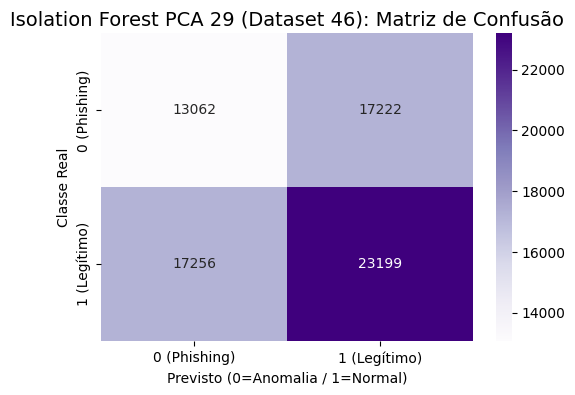


--- Relatório de Classificação Isolation Forest com PCA 29 (Dataset 46) ---
              precision    recall  f1-score   support

0 (Phishing)       0.43      0.43      0.43     30284
1 (Legítimo)       0.57      0.57      0.57     40455

    accuracy                           0.51     70739
   macro avg       0.50      0.50      0.50     70739
weighted avg       0.51      0.51      0.51     70739



In [ ]:
# Isolation Forest com PCA 29: Dataset 46

proporcao_phishing_46 = (y_train_46 == 0).sum() / len(y_train_46)

iso_forest_pca_46 = IsolationForest(contamination=proporcao_phishing_46, random_state=42, n_jobs=-1)
iso_forest_pca_46.fit(X_train_46_pca)

preds_test_if_pca_46 = iso_forest_pca_46.predict(X_test_46_pca)

y_pred_test_if_pca_46 = np.where(preds_test_if_pca_46 == -1, 0, 1)

cm_if_pca_46 = confusion_matrix(y_test_46, y_pred_test_if_pca_46)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_if_pca_46, annot=True, fmt='d', cmap='Purples',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('Isolation Forest PCA 29 (Dataset 46): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Previsto (0=Anomalia / 1=Normal)')
plt.show()

print("\n--- Relatório de Classificação Isolation Forest com PCA 29 (Dataset 46) ---")
print(classification_report(y_test_46, y_pred_test_if_pca_46, target_names=['0 (Phishing)', '1 (Legítimo)']))

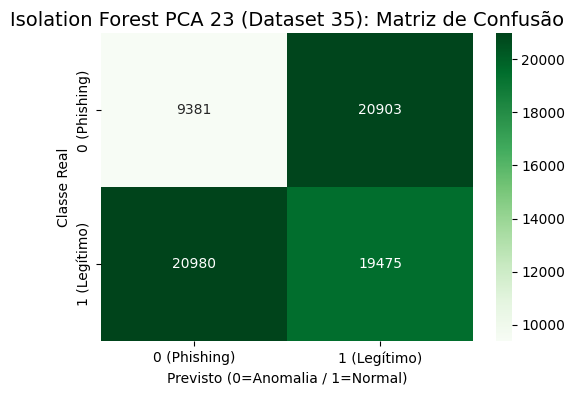


--- Relatório de Classificação Isolation Forest com PCA 23 (Dataset 35) ---
              precision    recall  f1-score   support

0 (Phishing)       0.31      0.31      0.31     30284
1 (Legítimo)       0.48      0.48      0.48     40455

    accuracy                           0.41     70739
   macro avg       0.40      0.40      0.40     70739
weighted avg       0.41      0.41      0.41     70739



In [ ]:
# Isolation Forest com PCA 23: Dataset 35

proporcao_phishing_35 = (y_train_35 == 0).sum() / len(y_train_35)

iso_forest_pca_35 = IsolationForest(contamination=proporcao_phishing_35, random_state=42, n_jobs=-1)
iso_forest_pca_35.fit(X_train_35_pca)

preds_test_if_pca_35 = iso_forest_pca_35.predict(X_test_35_pca)

y_pred_test_if_pca_35 = np.where(preds_test_if_pca_35 == -1, 0, 1)

cm_if_pca_35 = confusion_matrix(y_test_35, y_pred_test_if_pca_35)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_if_pca_35, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0 (Phishing)', '1 (Legítimo)'],
            yticklabels=['0 (Phishing)', '1 (Legítimo)'])
plt.title('Isolation Forest PCA 23 (Dataset 35): Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real')
plt.xlabel('Previsto (0=Anomalia / 1=Normal)')
plt.show()

print("\n--- Relatório de Classificação Isolation Forest com PCA 23 (Dataset 35) ---")
print(classification_report(y_test_35, y_pred_test_if_pca_35, target_names=['0 (Phishing)', '1 (Legítimo)']))

### Experimento Final: Isolation Forest com PCA

Para esgotar todas as possibilidades, agora testamos a aplicação da floresta de isolamento utilizando os dados já reduzidos pelo PCA.

Algoritmos baseados em árvores costumam ter dificuldade com o PCA, pois ele destrói os "eixos naturais" das variáveis para criar componentes artificiais. Contudo, como o PCA atua como um poderoso filtro de ruído, existia a hipótese de que um espaço de dados mais limpo pudesse facilitar o isolamento das anomalias.

#### Análise dos Resultados

A aplicação do PCA trouxe uma melhora marginal, mas não o suficiente para tornar o modelo viável para produção. O algoritmo saiu de um cenário pior que o cara ou coroa para um cenário que empata (cerca de 50%).

Ao compararmos as versões, um padrão se repete:
* **Dataset 46 (PCA 29) e Original (PCA 30):** Foram os modelos com "melhor" desempenho, atingindo 51% de acurácia e identificando cerca de 42% a 43% dos ataques de *phishing*.
* **Dataset Reduzido (PCA 25):** Sofreu uma queda para 45% de acurácia e apenas 36% de *recall* para *phishing*.
* **Dataset 35 (PCA 23):** Teve o pior desempenho geral, despencando para 41% de acurácia e meros 31% de *recall* na identificação das ameaças.

A leve melhora dos datasets maiores com o PCA indica que o filtro de ruído ajudou as árvores a não se perderem na imensidão de 50 dimensões. Entretanto, o que descobrimos no passo anterior foi reforçada: quanto mais simplificamos e comprimimos o dataset, mais "normais" os sites de phishing parecem ao algoritmo. Ao retirar variáveis, cortamos as poucas arestas estruturais que o algoritmo usava para tentar isolar o *phishing* como uma anomalia.

---

### Conclusão Final da Etapa Não-Supervisionada

A experimentação exaustiva com modelos não-supervisionados nos entregou *insights* inestimáveis sobre o PhiUSIIL Phishing URL Dataset:

1. **A Natureza do Phishing:** O fracasso da `Isolation Forest` prova que **URLs de phishing não são outliers**. Elas são instâncias densas projetadas estruturalmente para simular o tráfego legítimo. Ferramentas de detecção de anomalias clássicas não são adequadas.
2. O sucesso do `K-Means` revela que, apesar do *phishing* não ser uma anomalia isolada, ele forma um **cluster próprio com uma fronteira bem delimitada** quando projetado nos componentes principais do PCA.
3. O **Dataset 35 (com 23 componentes no PCA)** provou ser o mais eficiente. Ele eliminou ruídos e redundâncias ao máximo e ainda assim foi o modelo que entregou o melhor *recall* no K-Means (0.99), garantindo altíssima segurança computacional e matemática.

Com isso, temos uma boa base para contrastar com os resultados dos modelos supervisionados.